In [51]:
import numpy as np
import json
from pathlib import Path

from usecases.utils.test_nb_functions import plot_multiple_responses

## Чтение данных из csv-файлов

Директория с файлами и имена.

In [52]:
sample_dir = Path("usecases/test_samples/extra")
sample_file_name_list = ["test"]

In [53]:
data_list = []

In [54]:
interp_flag = False
ext = '.csv'

if sample_file_name_list is None:
    sample_file_name_list = [f.stem for f in sample_dir.glob('*'+ext)]

for sample_file_name in sample_file_name_list:
        data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)

Интерполяция данных (по требованию).

In [55]:
if interp_flag:
    data_list_interp = []
    for data in data_list:
        freq = data[0,:]
        mag_ph = np.array([data[1,:], data[2,:]])

        freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
        mag_ph_interp = np.array([np.interp(freq_log, freq, y) for y in mag_ph])
        data_interp = np.vstack((freq_log, mag_ph_interp))
        data_list_interp.append(data_interp)
    data_list = data_list_interp.copy()

In [56]:
Uout = 48
Pout_nom = 120
Uin = np.array([24, 36])
R = 40#Pout_nom/Uout * 2 # * np.array([1, 2])
L = 136e-6
C = 4 * 100e-6
ESR = 87e-3 / 4

Le = (Uout / Uin)**2 * L

w_c = 1 / (R*C)
w_ESR = 1 / (ESR*C)
w_RHP = R / Le

'''
fmin = 10
fmax = 50e3
N = 512
freq = np.logspace(np.log10(fmin),np.log10(fmax), N)
'''
freq = data_list[0][0,:]

s = 1j * freq * 2 * np.pi
gain_complex = Uin[0] / Uout * R/2 * (1 - s/w_RHP[0]) * (1 + s/w_ESR) / (1 + s/(2*w_c))# * np.exp(-s/100e3/2)

data = np.array([
    freq,
    20*np.log10(np.abs(gain_complex)),
    180 / np.pi * np.unwrap(np.angle(gain_complex))
])

data_list.append(data)

## Визуализация

In [57]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

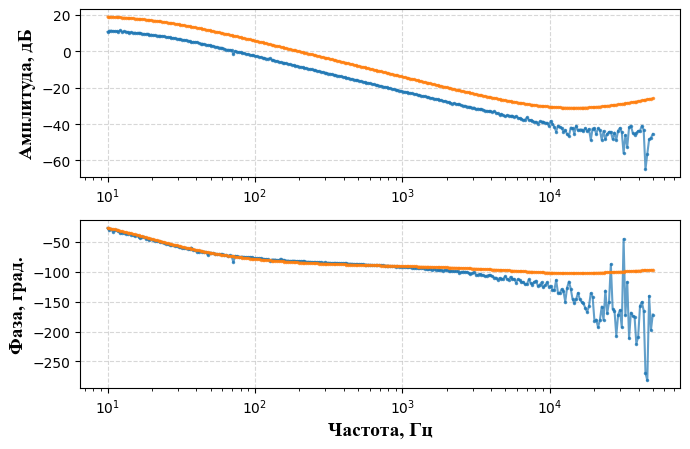

In [58]:
plot_multiple_responses(
    plot_config=PLOT_CONFIG,
    data_list=data_list
    )